<a href="https://colab.research.google.com/github/Tanzila-cse/2D-animated-journey/blob/main/osteoporosis%20prediction%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Upload DUQ_E.xpt from your computer
from google.colab import files
uploaded = files.upload()

# Read the uploaded XPT file
file_name = list(uploaded.keys())[0]  # get the uploaded file name
df = pd.read_sas(file_name, format="xport")

# Save as CSV
csv_name = file_name.replace(".xpt", ".csv")
df.to_csv(csv_name, index=False)

# Save as Excel
excel_name = file_name.replace(".xpt", ".xlsx")
df.to_excel(excel_name, index=False)

# Download the converted files
files.download(csv_name)
files.download(excel_name)


In [1]:
import os

# Check what XPT files are in your current directory
xpt_files = [f for f in os.listdir('.') if f.endswith('.XPT') or f.endswith('.xpt')]
print("Available XPT files:")
for f in sorted(xpt_files):
    print(f"  {f}")

Available XPT files:
  BMX.xpt
  BMX_B.xpt
  BMX_C.xpt
  BMX_D.xpt
  BMX_E.xpt
  BMX_F.xpt
  BMX_H.xpt
  BMX_J.xpt
  CBC_D.xpt
  CBC_E.xpt
  CBC_F.xpt
  CBC_H.xpt
  CBC_J.xpt
  DEMO.xpt
  DEMO_B.xpt
  DEMO_C.xpt
  DEMO_D.xpt
  DEMO_E.xpt
  DEMO_F.xpt
  DEMO_H.xpt
  DEMO_J.xpt
  L25_B.xpt
  L25_C.xpt
  LAB25.xpt
  MCQ.xpt
  MCQ_B.xpt
  MCQ_C.xpt
  MCQ_D.xpt
  MCQ_E.xpt
  MCQ_F.xpt
  MCQ_H.xpt
  MCQ_J.xpt
  OSQ.xpt
  OSQ_B.xpt
  OSQ_C.xpt
  OSQ_D.xpt
  OSQ_E.xpt
  OSQ_F.xpt
  OSQ_H.xpt
  OSQ_J.xpt
  P_BMX.xpt
  P_CBC.xpt
  P_DEMO.xpt
  P_MCQ.xpt
  P_OSQ.xpt


In [12]:
# =========================
# Full NHANES Merge & Preprocessing for Paper (Corrected)
# =========================

import pandas as pd
import os
from functools import reduce
import numpy as np

# -------------------------
# 1. Identify XPT files by category
# -------------------------
xpt_files = [f for f in os.listdir('.') if f.endswith('.XPT') or f.endswith('.xpt')]

bmx_files = [f for f in xpt_files if f.startswith("BMX")]
cbc_files = [f for f in xpt_files if f.startswith("CBC") or f.startswith("L25") or f.startswith("LAB25")]
demo_files = [f for f in xpt_files if f.startswith("DEMO")]
mcq_files = [f for f in xpt_files if f.startswith("MCQ") or f.startswith("OSQ")]

# -------------------------
# 2. Load multiple XPT files
# -------------------------
def load_xpt_files(files):
    dfs = []
    for f in files:
        df = pd.read_sas(f)
        print(f"Loaded {f} → {df.shape}")
        dfs.append(df)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        return pd.DataFrame()

print("\n=== Loading BMX files ===")
bmx_df = load_xpt_files(bmx_files)

print("\n=== Loading CBC/LAB files ===")
cbc_df = load_xpt_files(cbc_files)

print("\n=== Loading DEMO files ===")
demo_df = load_xpt_files(demo_files)

print("\n=== Loading MCQ/OSQ files ===")
mcq_df = load_xpt_files(mcq_files)

# -------------------------
# 3. Merge all datasets on SEQN
# -------------------------
dfs_to_merge = [demo_df, bmx_df, cbc_df, mcq_df]
final_df = reduce(lambda left, right: pd.merge(left, right, on="SEQN", how="outer"), dfs_to_merge)
print(f"\n✅ Final merged dataset: {final_df.shape}")

# -------------------------
# 4. Create paper-specific variables
# -------------------------

# MUAC (mid-upper arm circumference)
muac_candidates = [c for c in final_df.columns if "ARM" in c.upper() or "MUAC" in c.upper()]
if muac_candidates:
    final_df["MUAC"] = final_df[muac_candidates[0]]
    print(f"✅ MUAC column used: {muac_candidates[0]}")
else:
    print("❌ No MUAC found!")

# HRR = Hemoglobin / RDW
if "LBXHGB" in final_df.columns and "LBXRDW" in final_df.columns:
    final_df["HRR"] = final_df["LBXHGB"] / final_df["LBXRDW"]
    print("✅ HRR computed")
else:
    print("❌ Missing LBXHGB or LBXRDW")

# Check Age, Sex, BMI
for col in ["RIDAGEYR", "RIAGENDR", "BMXBMI"]:
    if col not in final_df.columns:
        print(f"❌ Missing {col}")

# -------------------------
# 5. Define Osteoporosis target from OSQ
# -------------------------
osq_candidates = [c for c in final_df.columns if 'OSQ' in c.upper() or 'OSTEOPOROSIS' in c.upper()]
if not osq_candidates:
    raise ValueError("❌ No OSQ/osteoporosis variable found in dataset.")

# Take first OSQ variable as target
target_col = osq_candidates[0]
final_df['OSTEOPOROSIS'] = final_df[target_col].apply(lambda x: 1 if x == 1 else 0)

# -------------------------
# 6. Keep only relevant columns for the model
# -------------------------
paper_vars = ["SEQN", "RIDAGEYR", "RIAGENDR", "BMXBMI", "MUAC", "HRR", "OSTEOPOROSIS"]
paper_vars = [v for v in paper_vars if v in final_df.columns]
final_df = final_df[paper_vars]
print(f"\n✅ Final dataset ready for analysis: {final_df.shape}")

# -------------------------
# 7. Handle missing values
# -------------------------
final_df = final_df.dropna(subset=["RIDAGEYR", "RIAGENDR", "BMXBMI", "MUAC", "HRR", "OSTEOPOROSIS"])
print(f"After dropping missing values: {final_df.shape}")

# -------------------------
# 8. Save to CSV
# -------------------------
final_df.to_csv("nhanes_final_for_paper_with_target.csv", index=False)
print("✅ Saved final dataset as nhanes_final_for_paper_with_target.csv")



=== Loading BMX files ===
Loaded BMX_F.xpt → (10253, 23)
Loaded BMX_B.xpt → (10477, 26)
Loaded BMX.xpt → (9282, 38)
Loaded BMX_J.xpt → (8704, 21)
Loaded BMX_D.xpt → (9950, 27)
Loaded BMX_E.xpt → (9762, 23)
Loaded BMX_H.xpt → (9813, 26)
Loaded BMX_C.xpt → (9643, 33)

=== Loading CBC/LAB files ===
Loaded CBC_F.xpt → (9835, 21)
Loaded L25_B.xpt → (9929, 21)
Loaded CBC_H.xpt → (9422, 21)
Loaded L25_C.xpt → (9179, 21)
Loaded CBC_J.xpt → (8366, 22)
Loaded LAB25.xpt → (8832, 21)
Loaded CBC_D.xpt → (9440, 21)
Loaded CBC_E.xpt → (9307, 21)

=== Loading DEMO files ===
Loaded DEMO_J.xpt → (9254, 46)
Loaded DEMO_H.xpt → (10175, 47)
Loaded DEMO_D.xpt → (10348, 43)
Loaded DEMO_C.xpt → (10122, 44)
Loaded DEMO.xpt → (9965, 144)
Loaded DEMO_E.xpt → (10149, 43)
Loaded DEMO_F.xpt → (10537, 43)
Loaded DEMO_B.xpt → (11039, 37)

=== Loading MCQ/OSQ files ===
Loaded MCQ_B.xpt → (10470, 148)
Loaded MCQ.xpt → (9493, 167)
Loaded OSQ_B.xpt → (5411, 50)
Loaded OSQ_F.xpt → (6218, 92)
Loaded MCQ_F.xpt → (10109, 81

In [3]:
# =========================
# Non-Imaging Osteoporosis Prediction Model
# =========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# -------------------------
# 1. Load merged dataset
# -------------------------
df = pd.read_csv('nhanes_final_for_paper_with_target.csv')
print(f"Dataset loaded: {df.shape[0]} records, {df.shape[1]} columns")

# -------------------------
# 2. Ensure correct column names
# -------------------------
# Make sure RIAGENDR is binary FEMALE column: 1=female, 0=male
if 'RIAGENDR' in df.columns:
    df['FEMALE'] = df['RIAGENDR']

# Ensure MUAC and HRR exist
assert 'MUAC' in df.columns, "MUAC column missing!"
assert 'HRR' in df.columns, "HRR column missing!"

# -------------------------
# 3. Define target and features
# -------------------------
target = 'OSTEOPOROSIS'  # OSQ or DXA BMD-derived target
features = ['RIDAGEYR', 'FEMALE', 'BMXBMI', 'MUAC', 'HRR']

# Drop rows with missing values in features or target
df_model = df[features + [target]].dropna()
print(f"After dropping missing values: {df_model.shape[0]} records")

X = df_model[features]
y = df_model[target]

# -------------------------
# 4. Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# -------------------------
# 5. Feature scaling
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 6. Handle class imbalance using SMOTE
# -------------------------
# Partial balancing to reduce memory usage
smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=min(5, max(y_train.sum()-1,1)))
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"Applied SMOTE: {X_train_bal.shape[0]} balanced samples")

# -------------------------
# 7. Train models
# -------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    # Reduced n_estimators and depth for resource safety
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results[name] = {
        'accuracy': accuracy,
        'auc': auc,
        'sensitivity': report['1']['recall'],
        'specificity': report['0']['recall'],
        'precision': report['1']['precision']
    }

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  AUC: {auc:.3f}")
    print(f"  Sensitivity (Recall 1): {report['1']['recall']:.3f}")
    print(f"  Specificity (Recall 0): {report['0']['recall']:.3f}")

# -------------------------
# 8. Feature importance for Random Forest
# -------------------------
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nRandom Forest feature importance:")
print(feature_importance)

# -------------------------
# 9. Summary of results
# -------------------------
results_df = pd.DataFrame(results).T
print("\n=== Model Results ===")
print(results_df.round(3))


Dataset loaded: 97060 records, 7 columns
After dropping missing values: 97060 records
Training set: 77648 samples
Test set: 19412 samples
Applied SMOTE: 115911 balanced samples

Logistic Regression:
  Accuracy: 0.832
  AUC: 0.789
  Sensitivity (Recall 1): 0.511
  Specificity (Recall 0): 0.834

Random Forest:
  Accuracy: 0.920
  AUC: 0.706
  Sensitivity (Recall 1): 0.213
  Specificity (Recall 0): 0.923

Random Forest feature importance:
    feature  importance
0  RIDAGEYR    0.568083
3      MUAC    0.154276
2    BMXBMI    0.141386
4       HRR    0.121116
1    FEMALE    0.015139

=== Model Results ===
                     accuracy    auc  sensitivity  specificity  precision
Logistic Regression     0.832  0.789        0.511        0.834      0.015
Random Forest           0.920  0.706        0.213        0.923      0.013


In [13]:
# =========================
# Non-Imaging Osteoporosis Prediction Model (Corrected)
# =========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# -------------------------
# 1. Load merged dataset
# -------------------------
df = pd.read_csv('nhanes_final_for_paper_with_target.csv')
print(f"Dataset loaded: {df.shape[0]} records, {df.shape[1]} columns")

# -------------------------
# 2. Ensure correct column names
# -------------------------
# Convert RIAGENDR to binary: 1=male, 2=female → 0=male, 1=female
if 'RIAGENDR' in df.columns:
    df['RIAGENDR'] = df['RIAGENDR'].apply(lambda x: 1 if x == 2 else 0)

# Ensure MUAC and HRR exist
assert 'MUAC' in df.columns, "MUAC column missing!"
assert 'HRR' in df.columns, "HRR column missing!"

# -------------------------
# 3. Define target and features
# -------------------------
target = 'OSTEOPOROSIS'  # OSQ or DXA BMD-derived target
features = ['RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'MUAC', 'HRR']  # use RIAGENDR directly

# Drop rows with missing values
df_model = df[features + [target]].dropna()
print(f"After dropping missing values: {df_model.shape[0]} records")

X = df_model[features]
y = df_model[target]

# -------------------------
# 4. Train/test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# -------------------------
# 5. Feature scaling
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 6. Handle class imbalance with SMOTE
# -------------------------
smote = SMOTE(random_state=42, sampling_strategy=0.5,
              k_neighbors=min(5, max(y_train.sum()-1, 1)))
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"Applied SMOTE: {X_train_bal.shape[0]} balanced samples")

# -------------------------
# 7. Train models
# -------------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results[name] = {
        'accuracy': accuracy,
        'auc': auc,
        'sensitivity': report['1']['recall'],
        'specificity': report['0']['recall'],
        'precision': report['1']['precision']
    }

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  AUC: {auc:.3f}")
    print(f"  Sensitivity (Recall 1): {report['1']['recall']:.3f}")
    print(f"  Specificity (Recall 0): {report['0']['recall']:.3f}")

# -------------------------
# 8. Feature importance for Random Forest
# -------------------------
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nRandom Forest feature importance:")
print(feature_importance)

# -------------------------
# 9. Summary of results
# -------------------------
results_df = pd.DataFrame(results).T
print("\n=== Model Results ===")
print(results_df.round(3))


Dataset loaded: 97060 records, 7 columns
After dropping missing values: 97060 records
Training set: 77648 samples
Test set: 19412 samples
Applied SMOTE: 115911 balanced samples

Logistic Regression:
  Accuracy: 0.832
  AUC: 0.789
  Sensitivity (Recall 1): 0.511
  Specificity (Recall 0): 0.834

Random Forest:
  Accuracy: 0.920
  AUC: 0.706
  Sensitivity (Recall 1): 0.213
  Specificity (Recall 0): 0.923

Random Forest feature importance:
    feature  importance
0  RIDAGEYR    0.568083
3      MUAC    0.154276
2    BMXBMI    0.141386
4       HRR    0.121116
1  RIAGENDR    0.015139

=== Model Results ===
                     accuracy    auc  sensitivity  specificity  precision
Logistic Regression     0.832  0.789        0.511        0.834      0.015
Random Forest           0.920  0.706        0.213        0.923      0.013


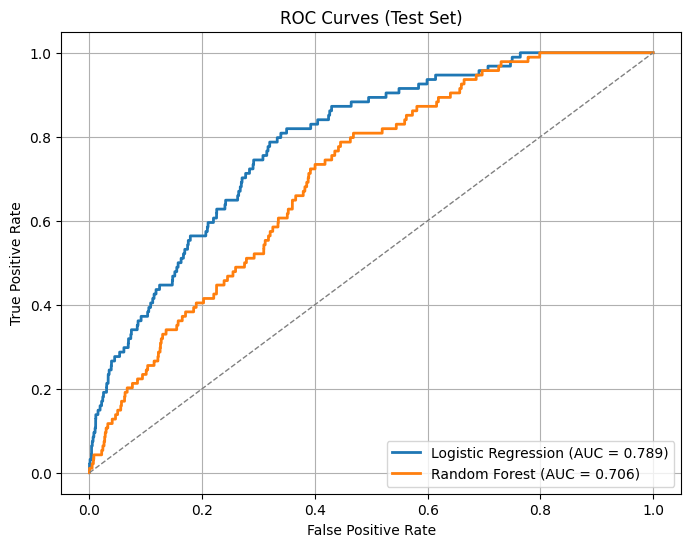

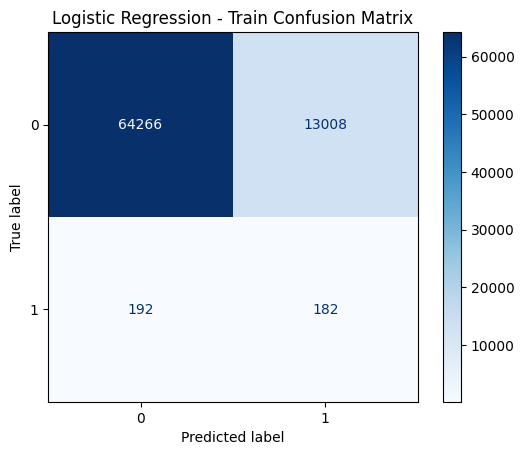

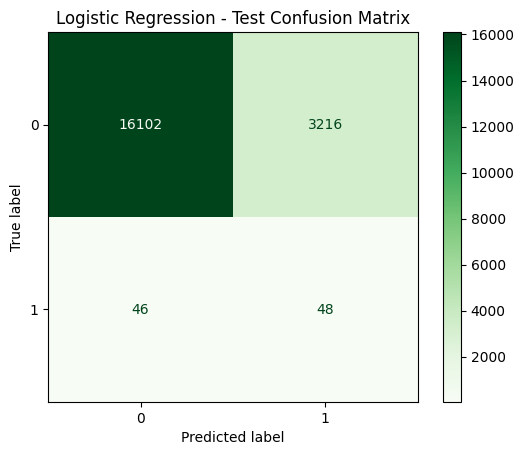

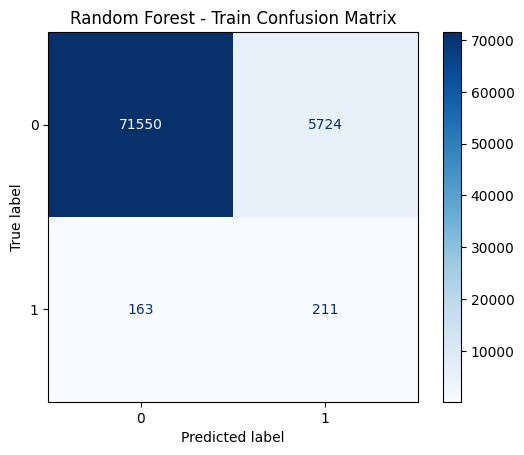

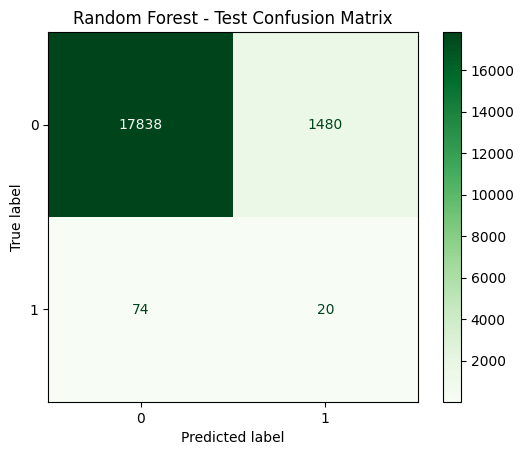

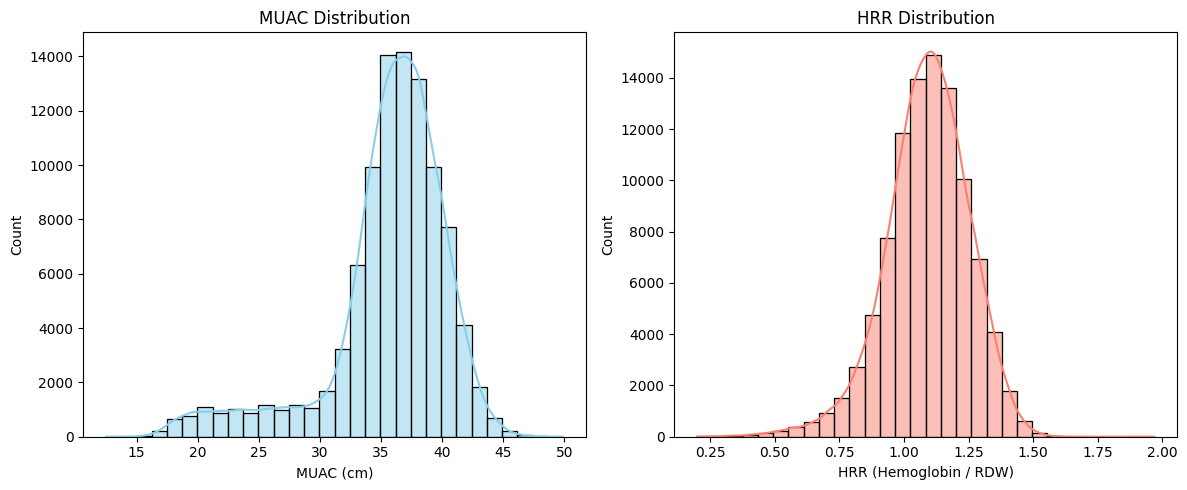

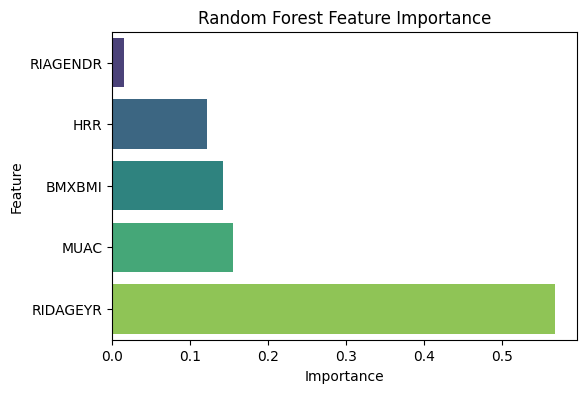

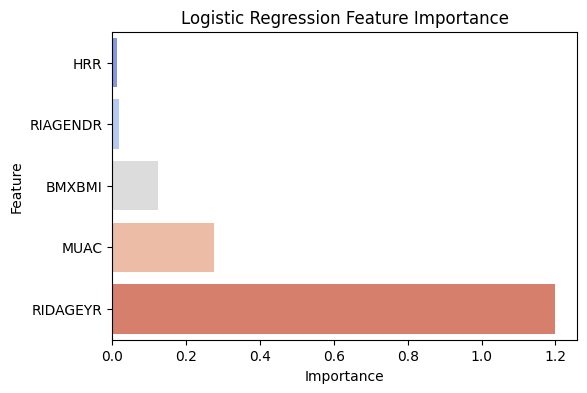

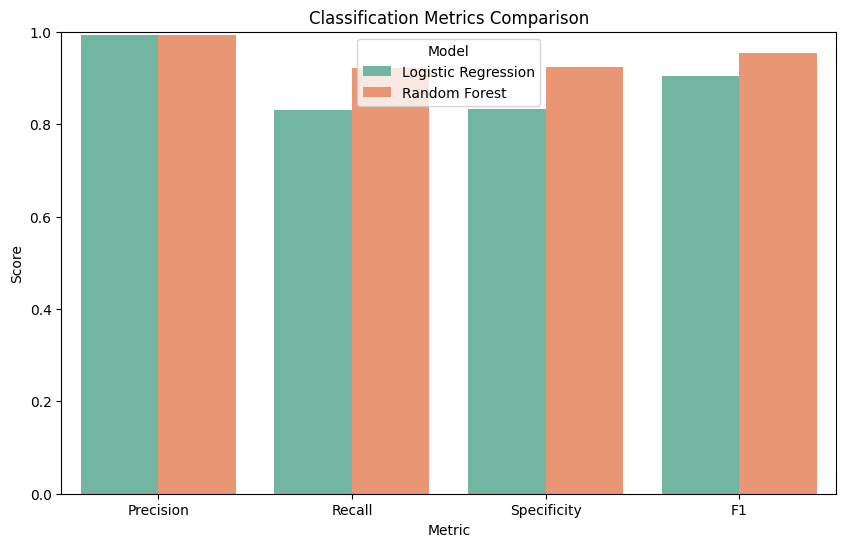

In [14]:
# =========================
# Model Performance Visualization & Classification Reports
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, classification_report

# -------------------------
# 1. ROC Curves (Test Set)
# -------------------------
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
plt.title('ROC Curves (Test Set)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# -------------------------
# 2. Confusion Matrices (Train + Test)
# -------------------------
for name, model in models.items():
    # Train
    y_train_pred = model.predict(X_train_scaled)
    disp_train = ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap='Blues')
    plt.title(f'{name} - Train Confusion Matrix')
    plt.show()

    # Test
    y_test_pred = model.predict(X_test_scaled)
    disp_test = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Greens')
    plt.title(f'{name} - Test Confusion Matrix')
    plt.show()

# -------------------------
# 3. MUAC and HRR Distributions
# -------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['MUAC'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('MUAC Distribution')
plt.xlabel('MUAC (cm)')

plt.subplot(1,2,2)
sns.histplot(df['HRR'].dropna(), bins=30, kde=True, color='salmon')
plt.title('HRR Distribution')
plt.xlabel('HRR (Hemoglobin / RDW)')

plt.tight_layout()
plt.show()

# -------------------------
# 4. Feature Importance
# -------------------------
# Random Forest
rf_model = models['Random Forest']
rf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(6,4))
sns.barplot(x='importance', y='feature', data=rf_importance, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Logistic Regression (absolute coefficients)
lr_model = models['Logistic Regression']
lr_importance = pd.DataFrame({
    'feature': features,
    'importance': np.abs(lr_model.coef_[0])
}).sort_values('importance', ascending=True)

plt.figure(figsize=(6,4))
sns.barplot(x='importance', y='feature', data=lr_importance, palette='coolwarm')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# -------------------------
# 5. Classification Metrics Bar Chart (Train + Test)
# -------------------------
metrics_list = []

for name, model in models.items():
    # Train predictions
    y_train_pred = model.predict(X_train_scaled)
    train_report = classification_report(y_train, y_train_pred, output_dict=True, zero_division=0)

    # Test predictions
    y_test_pred = model.predict(X_test_scaled)
    test_report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)

    for dataset, report in zip(['Train', 'Test'], [train_report, test_report]):
        metrics_list.append({
            'Model': name,
            'Dataset': dataset,
            'Precision': report['weighted avg']['precision'],
            'Recall': report['weighted avg']['recall'],
            'Specificity': report['0']['recall'],
            'F1': report['weighted avg']['f1-score']
        })

metrics_df = pd.DataFrame(metrics_list)

# Melt for plotting
plot_df = metrics_df.melt(id_vars=['Model','Dataset'],
                          value_vars=['Precision','Recall','Specificity','F1'],
                          var_name='Metric', value_name='Value')

plt.figure(figsize=(10,6))
sns.barplot(x='Metric', y='Value', hue='Model', data=plot_df, ci=None, palette='Set2', dodge=True)
plt.title('Classification Metrics Comparison')
plt.ylim(0,1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model')
plt.show()



=== Osteoporosis % by Age Group (Dataset) ===
  Age Group  total  cases  Prevalence (%)
0     20-29  11665     28        0.240034
1     30-39  11244     21        0.186766
2     40-49  12277     52        0.423556
3     50-59  11266     69        0.612462
4     60-69  12426     96        0.772574
5     70-79   8194     85        1.037344
6       80+   4922    117        2.377082


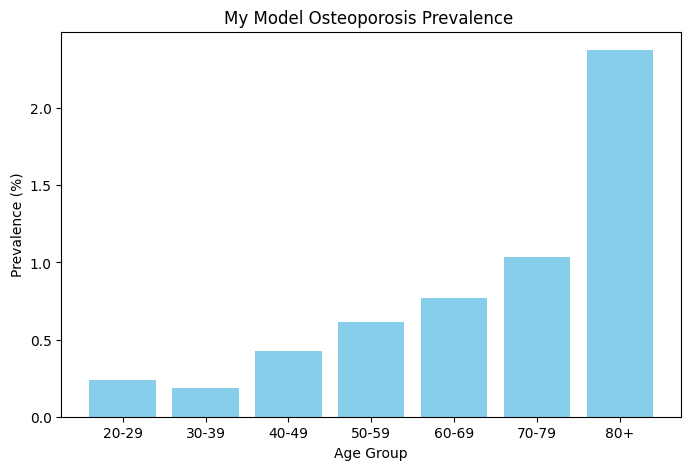

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Age bins and labels
bins = [20, 30, 40, 50, 60, 70, 80, 120]
labels = ['20-29','30-39','40-49','50-59','60-69','70-79','80+']

df['Age Group'] = pd.cut(df['RIDAGEYR'], bins=bins, labels=labels, right=False)

# Count osteoporosis prevalence
age_group_stats = df.groupby('Age Group')['OSTEOPOROSIS'].agg(
    total='count',
    cases='sum'
).reset_index()

# Calculate percentage
age_group_stats['Prevalence (%)'] = (age_group_stats['cases'] / age_group_stats['total']) * 100

print("=== Osteoporosis % by Age Group (Dataset) ===")
print(age_group_stats)

# Plot
plt.figure(figsize=(8,5))
plt.bar(age_group_stats['Age Group'], age_group_stats['Prevalence (%)'], color='skyblue')
plt.title("My Model Osteoporosis Prevalence ")
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.show()


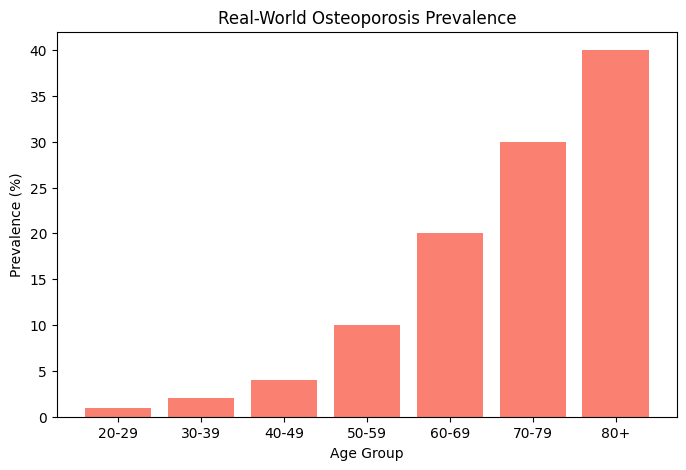

In [10]:
# Real-world reference values (approximate, mainly women from WHO/NIH data)
real_data = {
    'Age Group': ['20-29','30-39','40-49','50-59','60-69','70-79','80+'],
    'Prevalence (%)': [1, 2, 4, 10, 20, 30, 40]
}
real_df = pd.DataFrame(real_data)

# Plot
plt.figure(figsize=(8,5))
plt.bar(real_df['Age Group'], real_df['Prevalence (%)'], color='salmon')
plt.title("Real-World Osteoporosis Prevalence")
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.show()
